# **Major Project of Data Analysis with AI by JAYDEV HIRENBHAI BHATT**  

## 1. Import Libraries

# Seasonal Agriculture Performance Analysis

**Major Project — VOIS AICTE Batch 1 (2026-2027)**

**Domain** :- Agriculture

**Project Theme**:- Seasonal Agriculture Performance


**Objective:** Analyze agricultural data collected across three cropping seasons (Kharif, Rabi, Zaid)
to identify meaningful seasonal patterns, trends, relationships and differences in agricultural
performance, and to derive evidence-based recommendations for seasonal agricultural planning.

**Dataset:** `seasonal_agriculture_performance_dataset.csv` — 4,000 farm-level records across 8 states,
10 districts, 8 crops, 3 seasons and 4 irrigation methods, covering environmental conditions, resource
usage, and economic performance (cost, revenue, profit).


 **Problem Statement** :-

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

**Objectives**:-

 Explore and understand the dataset.  
 Clean and prepare the data for analysis.  
 Examine how agricultural performance varies across seasons.  
 Identify important seasonal patterns and trends.  
 Investigate relationships between seasonal conditions and agricultural outcomes.  
 Compare relevant groups within different seasons.  
 Identify significant differences or unusual patterns.  
 Apply appropriate statistical and visualization techniques.  
 Interpret findings based on evidence from the dataset.  
 Develop meaningful conclusions and data-driven recommendations.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Dataset

In [56]:
#Loading the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print('Dataset loaded successfully:', df.shape[0], 'rows,', df.shape[1], 'columns')


Dataset loaded successfully: 4000 rows, 28 columns


## 3. Initial Data Exploration

Reviewing the top rows, structure, column names and data types before doing any cleaning.

In [57]:
#review top 5 rows
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [58]:
df.tail() #Last five rows.


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [59]:
#Number of rows and columns
df.shape


(4000, 28)

In [60]:
#column names
df.columns.to_list()


['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [61]:
#data types of each column
df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [62]:
#full structural summary
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 4. Data Quality Check — Duplicate Records

`Farm_ID` is expected to be a unique identifier for each farm record. Checking for both fully
duplicated rows and duplicated IDs.

In [63]:
#data quality check - duplicates
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['Farm_ID'].duplicated().sum()
print('Fully duplicated rows:', duplicate_rows)
print('Duplicated Farm_ID values:', duplicate_ids)


Fully duplicated rows: 0
Duplicated Farm_ID values: 0


In [64]:
# No duplicate rows or IDs were found, so no records need to be dropped.
# The line below is kept so the notebook remains correct even if duplicates existed.
df = df.drop_duplicates().copy()
print('Rows after duplicate removal:', df.shape[0])


Rows after duplicate removal: 4000


## 5. Missing Value Analysis & Treatment

Identifying which columns have missing values, then choosing a treatment strategy for each based on
what the column represents — rather than applying one rule to every column.

In [65]:
#checking null values
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0]
missing.sort_values('Missing Count', ascending=False)


,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


Three columns have missing values, all under 1.2% of rows: `Rainfall_mm`, `Soil_Moisture_pct` and
`Yield_Tonnes_Ha`. Since the missing share is small, imputation is preferred over dropping rows (dropping
would lose otherwise-complete records).

- **Rainfall_mm** and **Soil_Moisture_pct** are environmental variables driven mainly by *when* (season)
  and *where* (region) a farm is, not by which crop is grown — so they are imputed with the **median
  for that Season**.
- **Yield_Tonnes_Ha** varies enormously by crop (e.g. sugarcane yields are naturally tens of times higher
  than wheat or pulses in tonnes/hectare) — so it is imputed with the **median for that Crop**, which
  preserves crop-specific scale far better than a single overall median would.

In [66]:
# Environmental columns: impute using the median for the same Season.
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Yield depends heavily on crop type, so impute using the median for the same Crop.
df['Yield_Tonnes_Ha'] = df.groupby('Crop')['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))


In [67]:
#verifying no missing values remain
missing_after = df.isna().sum()
print('Total remaining missing values:', missing_after.sum())
missing_after[missing_after > 0]


Total remaining missing values: 0


,0


## 6. Descriptive / Statistical Analysis

In [68]:
#stastical information - numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.700,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [69]:
#stastical information - categorical columns
df.describe(include='object').T


,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [70]:
# Display unique values and their counts for all categorical columns
print("\n--- Unique values and counts for Categorical Columns ---")
for col in df.select_dtypes(include='object').columns:
    if col != 'Farm_ID': # Farm_ID is unique for all rows, so exclude for brevity
        print(f"\nColumn: {col} ({df[col].nunique()} unique values)")
        print(df[col].value_counts())



--- Unique values and counts for Categorical Columns ---

Column: State (8 unique values)
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Column: District (10 unique values)
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Column: Crop (8 unique values)
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Column: Season (3 unique values)
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Column: Irrigation_Method (4 unique values)
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int

In [71]:
#quick look at category sizes for the main grouping columns
for col in ['Season', 'Crop', 'State', 'Irrigation_Method']:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()


--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



## 7. Outlier Investigation

Checking numeric columns for outliers using boxplots and the IQR rule. Financial and yield-related
columns (`Yield_Tonnes_Ha`, `Production_Tonnes`, `Revenue_INR`, `Water_Used_m3`) are investigated
separately, since this dataset intentionally mixes very different crops (e.g. sugarcane vs pulses),
and a value that looks like an outlier overall may simply be normal for a particular crop.

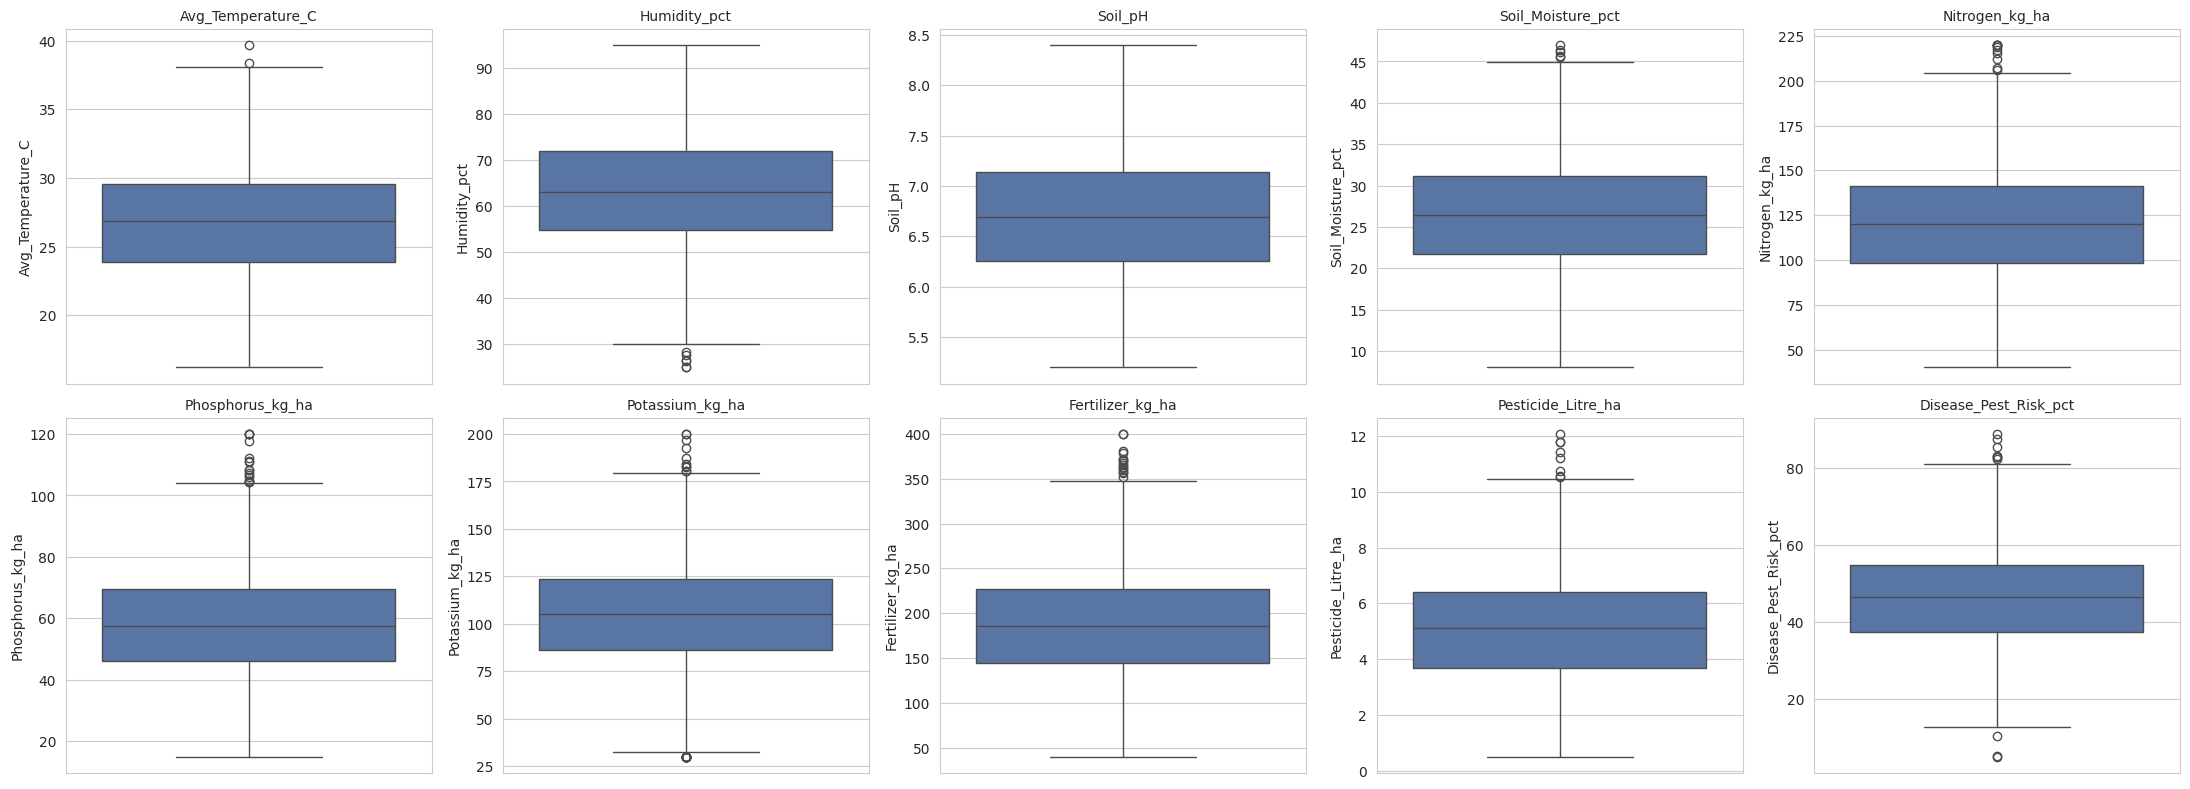

In [72]:
#boxplots for environmental and agronomic-input columns
env_cols = ['Avg_Temperature_C', 'Humidity_pct', 'Soil_pH', 'Soil_Moisture_pct',
            'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
            'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Disease_Pest_Risk_pct']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
for i, col in enumerate(env_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


In [73]:
#IQR-based outlier count for the columns above
def count_outliers(col_name):
    Q1, Q3 = col_name.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    return ((col_name < lower_range) | (col_name > upper_range)).sum(), lower_range, upper_range

for col in env_cols:
    n_out, low, high = count_outliers(df[col])
    print(f'{col:25s} outliers={n_out:4d}  valid range=({low:.2f}, {high:.2f})')


Avg_Temperature_C         outliers=   2  valid range=(15.35, 38.15)
Humidity_pct              outliers=   6  valid range=(29.09, 97.59)
Soil_pH                   outliers=   0  valid range=(4.94, 8.46)
Soil_Moisture_pct         outliers=   5  valid range=(7.45, 45.45)
Nitrogen_kg_ha            outliers=  10  valid range=(34.41, 205.31)
Phosphorus_kg_ha          outliers=  16  valid range=(11.40, 104.20)
Potassium_kg_ha           outliers=  32  valid range=(30.10, 179.70)
Fertilizer_kg_ha          outliers=  15  valid range=(19.14, 352.04)
Pesticide_Litre_ha        outliers=   8  valid range=(-0.38, 10.46)
Disease_Pest_Risk_pct     outliers=  10  valid range=(10.90, 81.30)


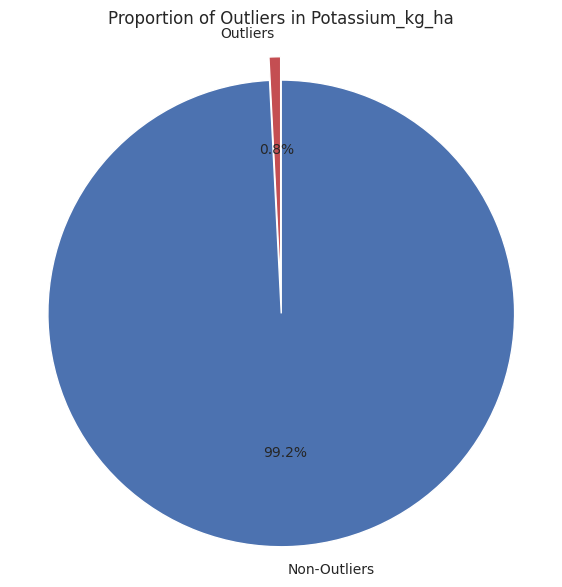

In [74]:
import matplotlib.pyplot as plt

# Pie chart for Potassium_kg_ha outliers based on the previous output (32 outliers out of 4000 records)
num_records = df.shape[0]
outliers_potassium = 32 # From the output of the previous cell for Potassium_kg_ha
non_outliers_potassium = num_records - outliers_potassium

labels = ['Outliers', 'Non-Outliers']
sizes = [outliers_potassium, non_outliers_potassium]
colors = ['#C44E52', '#4C72B0']
explode = (0.1, 0)  # Emphasize the 'Outliers' slice

fig = plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Outliers in Potassium_kg_ha')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

`Potassium_kg_ha` and `Fertilizer_kg_ha` show the most outliers among the agronomic-input columns.
These are dosage columns that should not vary by crop as drastically as yield does, so it is reasonable
to cap them using the IQR rule (same approach used in the crop recommendation reference notebook).

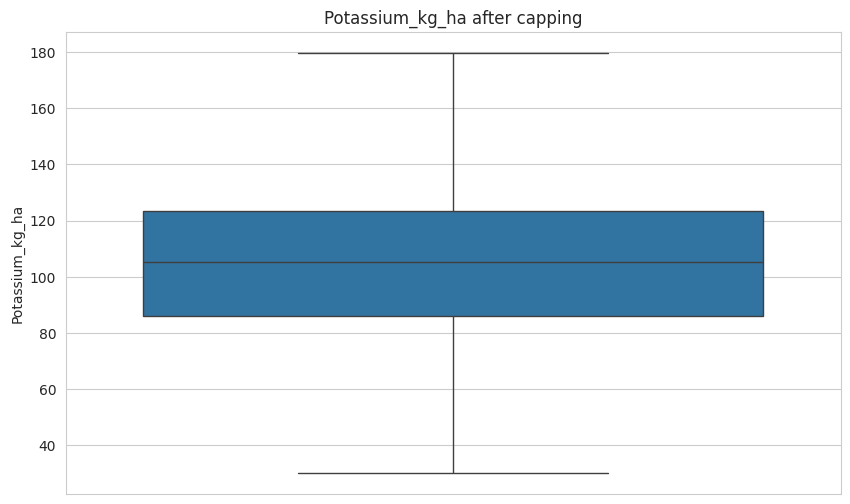

In [75]:
#cap Potassium_kg_ha and Fertilizer_kg_ha using the IQR rule
def cap_outliers(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    return np.where(series > upper_range, upper_range, np.where(series < lower_range, lower_range, series))

df['Potassium_kg_ha'] = cap_outliers(df['Potassium_kg_ha'])
df['Fertilizer_kg_ha'] = cap_outliers(df['Fertilizer_kg_ha'])

sns.boxplot(y='Potassium_kg_ha', data=df)
plt.title('Potassium_kg_ha after capping')
plt.show()


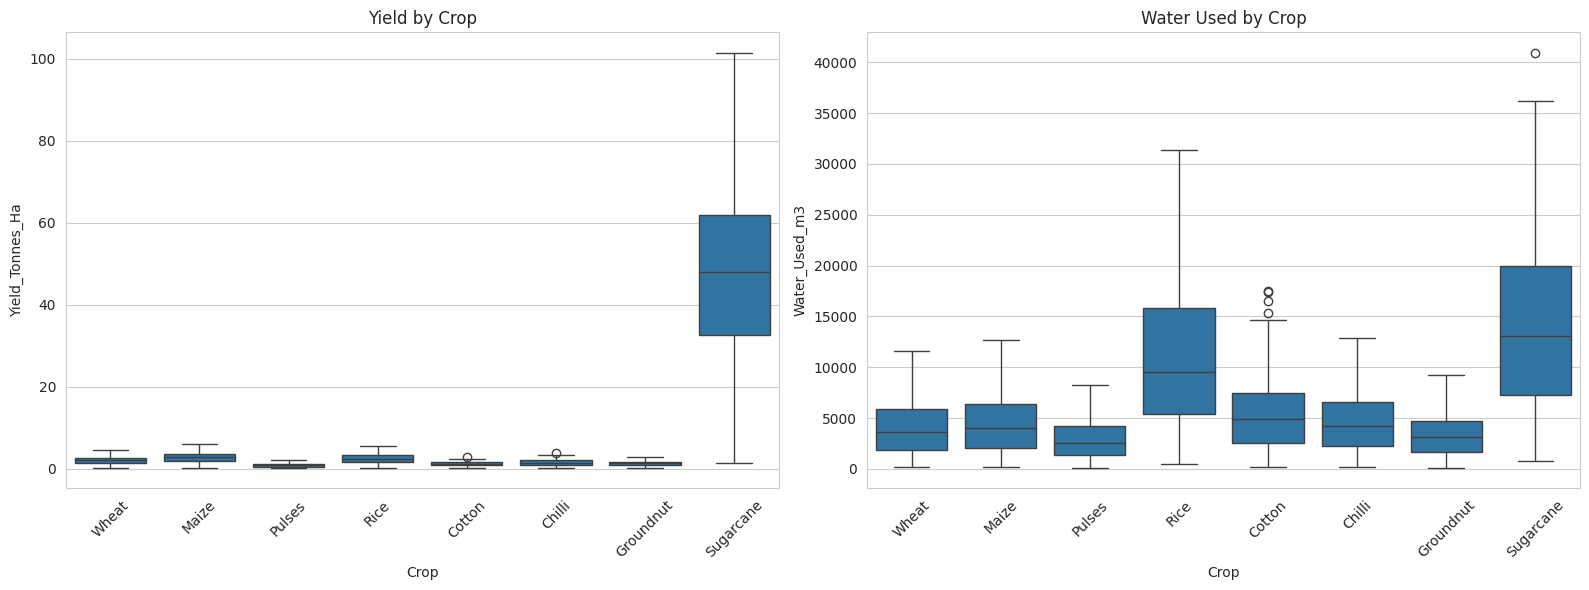

In [76]:
#Now checking Yield, Production, Revenue and Water_Used - are the 'outliers' really errors?
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x='Crop', y='Yield_Tonnes_Ha', data=df, ax=axes[0])
axes[0].set_title('Yield by Crop')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Crop', y='Water_Used_m3', data=df, ax=axes[1])
axes[1].set_title('Water Used by Crop')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [77]:
#confirming which crops drive the 'outliers' in Water_Used_m3
q1, q3 = df['Water_Used_m3'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
print('Crops behind Water_Used_m3 outliers (>', round(high), 'm3):')
print(df.loc[df['Water_Used_m3'] > high, 'Crop'].value_counts())


Crops behind Water_Used_m3 outliers (> 16171 m3):
Crop
Rice         168
Sugarcane    105
Cotton         3
Name: count, dtype: int64


**Decision:** `Yield_Tonnes_Ha`, `Production_Tonnes`, `Revenue_INR` and `Water_Used_m3` are **not**
capped. The boxplot by crop and the crop breakdown above show that the high values are almost entirely
**Rice** and **Sugarcane** — both genuinely water-intensive, higher-yielding crops in real agriculture.
Applying a single dataset-wide IQR rule to these columns would incorrectly remove real, meaningful
crop-driven variation rather than data errors.

## 8. Univariate Analysis

Looking at the distribution of individual variables — categorical counts and numeric distributions.

/tmp/ipykernel_6827/877195463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Season', data=df, order=['Kharif', 'Rabi', 'Zaid'], ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_6827/877195463.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Crop', data=df, order=df['Crop'].value_counts().index, ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_6827/877195463.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Irrigation_Method', data=df, order=df['Irrigation_Method'].value_counts().index,
/tmp/ipykernel_6827/877195463.py:13:

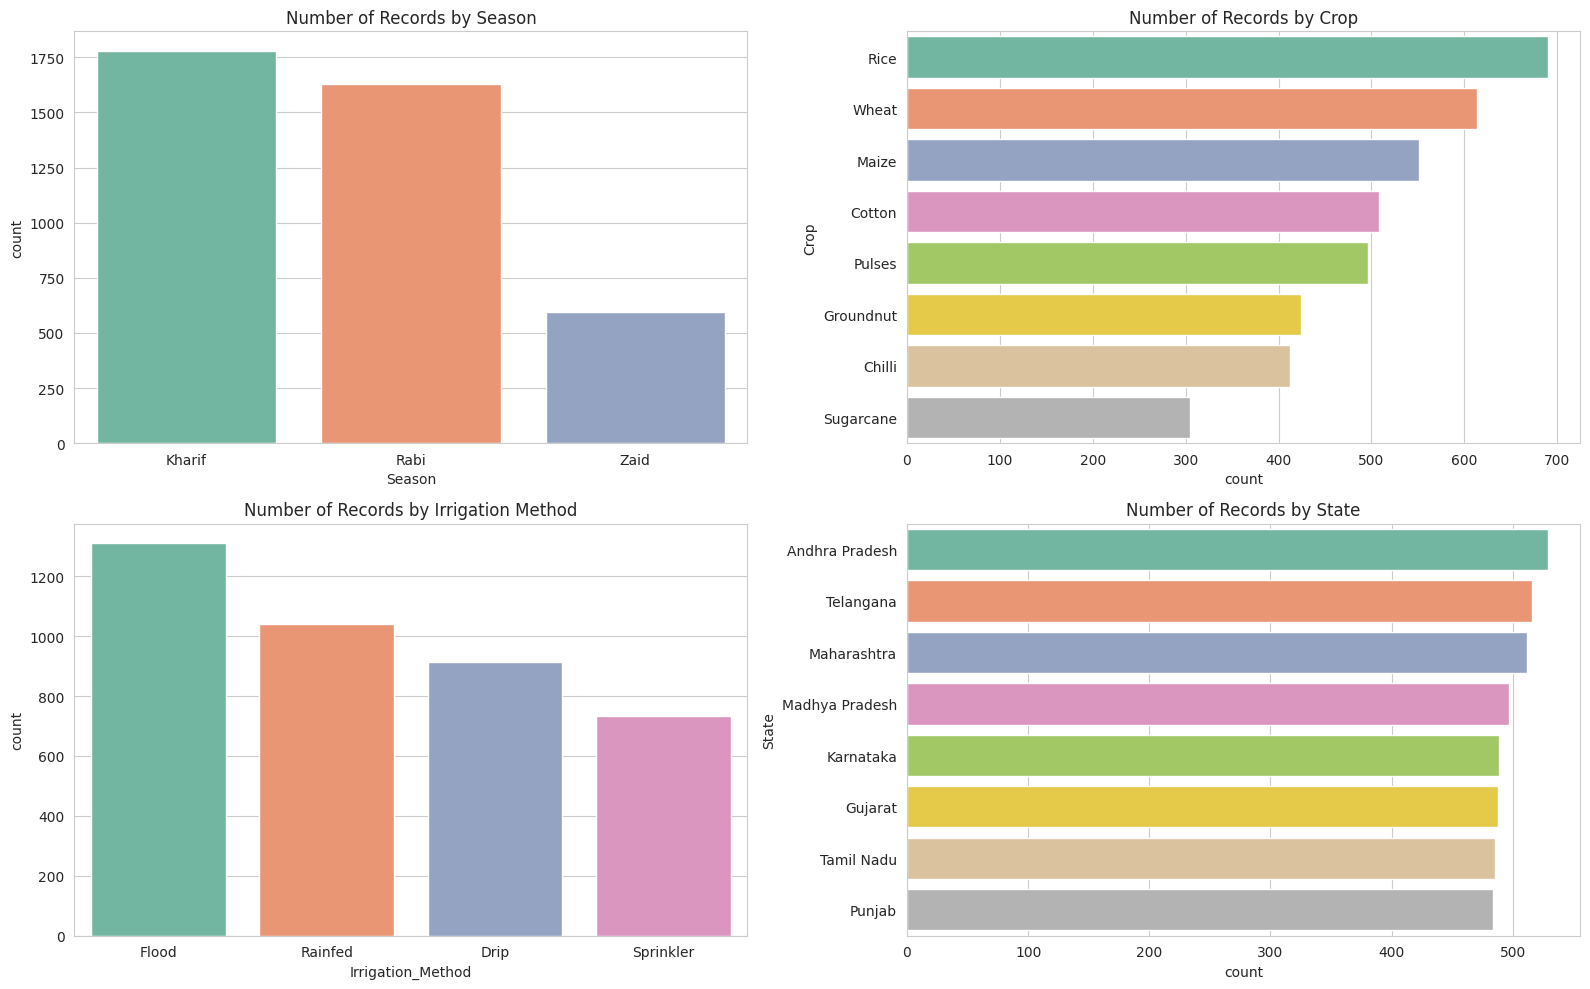

In [78]:
#categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.countplot(x='Season', data=df, order=['Kharif', 'Rabi', 'Zaid'], ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Number of Records by Season')

sns.countplot(y='Crop', data=df, order=df['Crop'].value_counts().index, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Number of Records by Crop')

sns.countplot(x='Irrigation_Method', data=df, order=df['Irrigation_Method'].value_counts().index,
              ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Number of Records by Irrigation Method')

sns.countplot(y='State', data=df, order=df['State'].value_counts().index, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Number of Records by State')
plt.tight_layout()
plt.show()


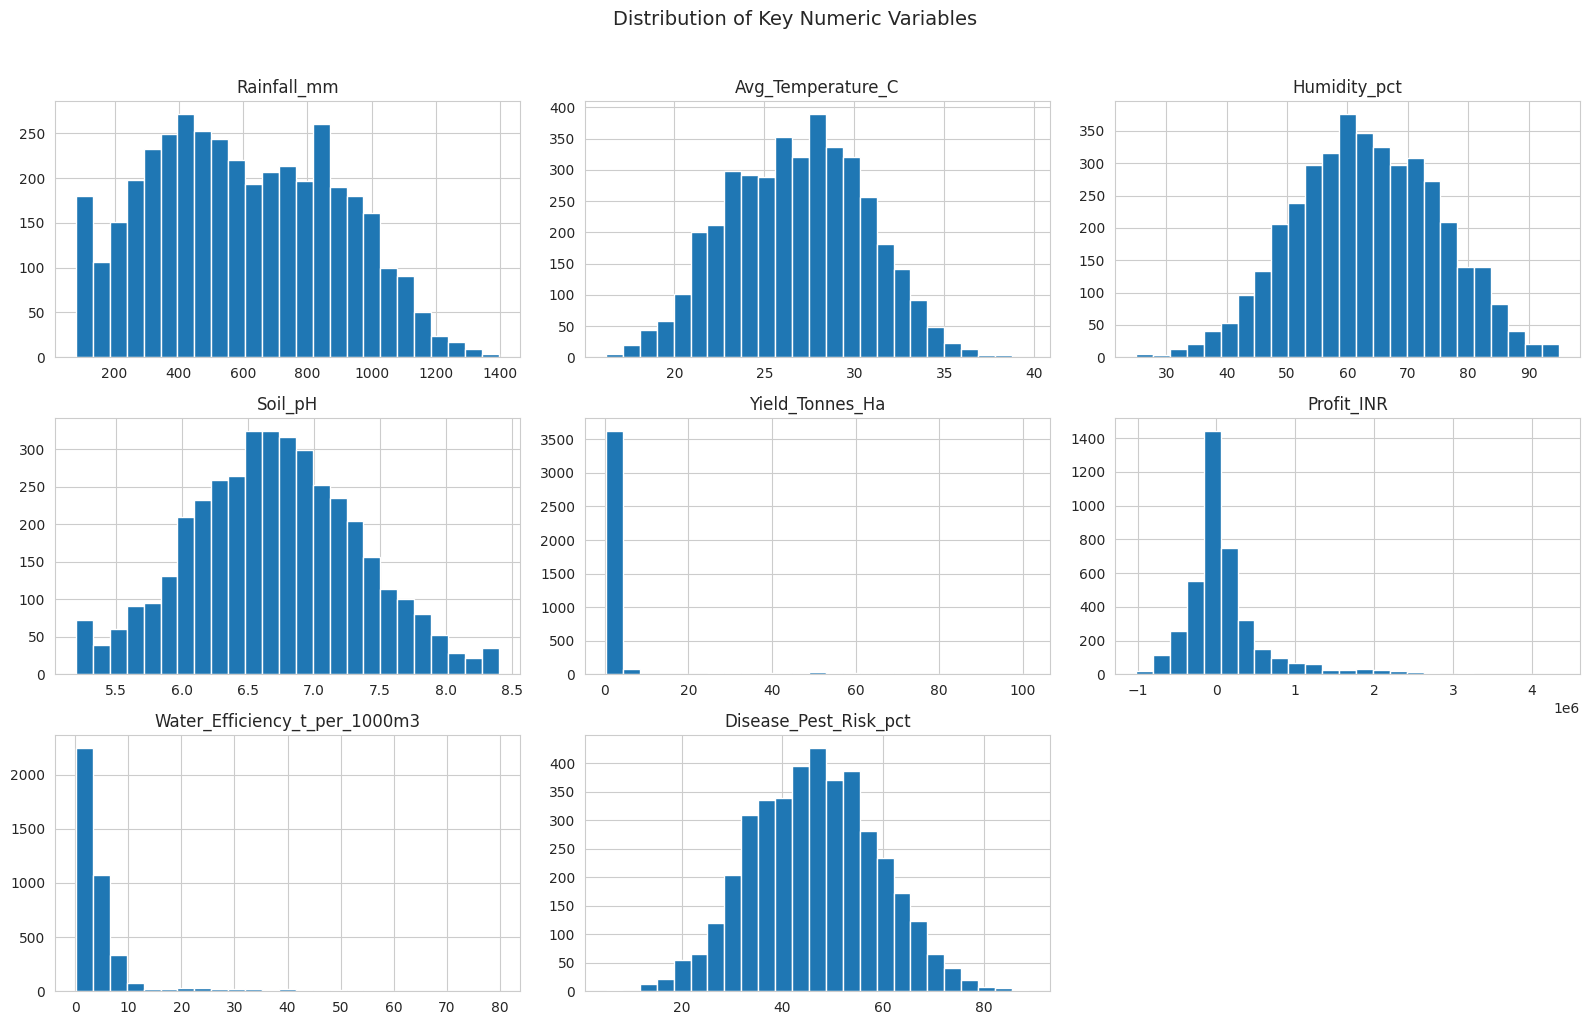

In [79]:
#numeric distributions
num_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_pH',
            'Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
df[num_cols].hist(bins=25, figsize=(16, 10))
plt.suptitle('Distribution of Key Numeric Variables', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Share of farm records with negative profit: 49.1%


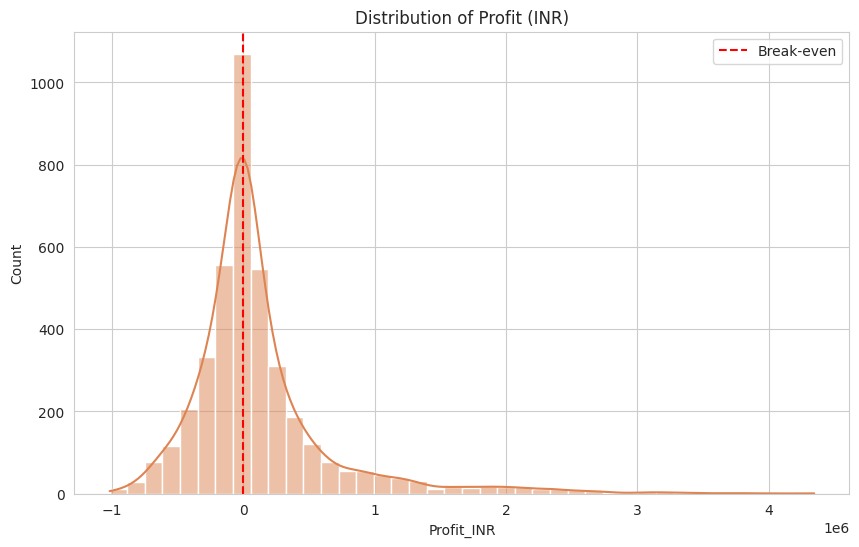

In [80]:
#Profit_INR deserves a closer look - how many farms are actually running at a loss?
loss_pct = (df['Profit_INR'] < 0).mean() * 100
print(f'Share of farm records with negative profit: {loss_pct:.1f}%')

plt.figure(figsize=(10, 6))
sns.histplot(df['Profit_INR'], bins=40, kde=True, color='#DD8452')
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.title('Distribution of Profit (INR)')
plt.legend()
plt.show()


## 9. Bivariate Analysis

Examining relationships between pairs of variables.

/tmp/ipykernel_6827/488865016.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, order=['Kharif', 'Rabi', 'Zaid'], palette='Set2')


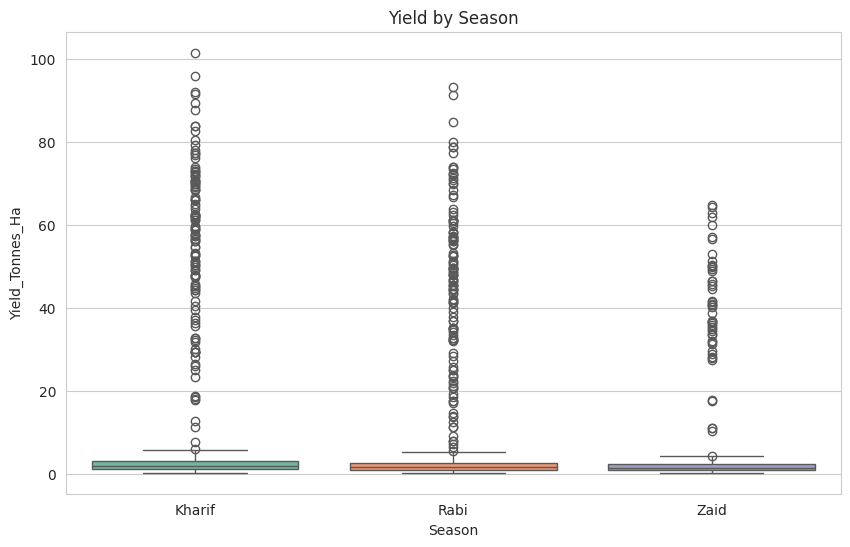

In [81]:
#Season vs Yield
plt.figure(figsize=(10, 6))
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df, order=['Kharif', 'Rabi', 'Zaid'], palette='Set2')
plt.title('Yield by Season')
plt.show()


/tmp/ipykernel_6827/747084501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', data=df,


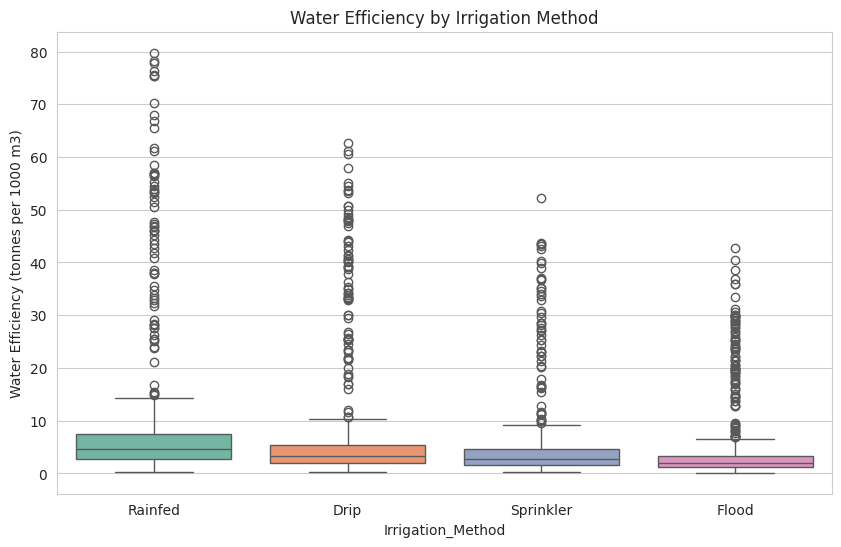

In [82]:
#Irrigation Method vs Water Efficiency
plt.figure(figsize=(10, 6))
sns.boxplot(x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', data=df,
            order=df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean()
                    .sort_values(ascending=False).index, palette='Set2')
plt.title('Water Efficiency by Irrigation Method')
plt.ylabel('Water Efficiency (tonnes per 1000 m3)')
plt.show()


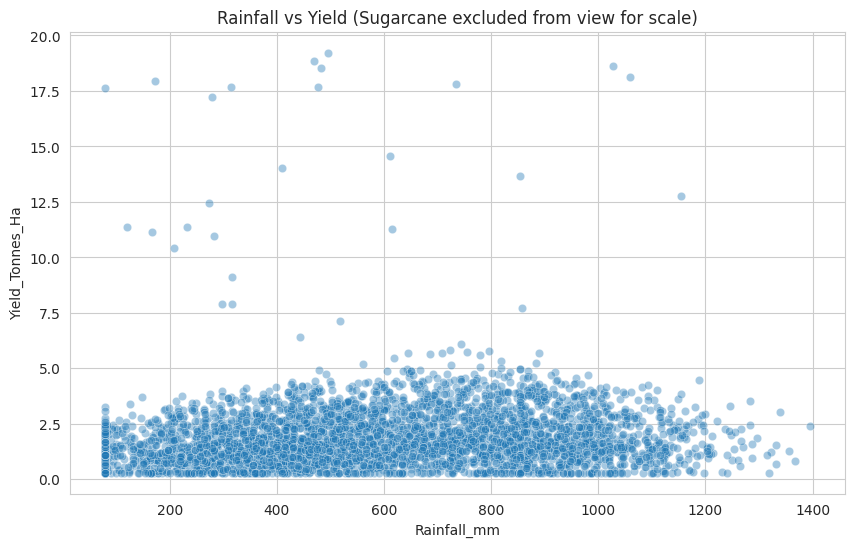

In [83]:
#Rainfall vs Yield
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', data=df[df['Yield_Tonnes_Ha'] < 20], alpha=0.4)
plt.title('Rainfall vs Yield (Sugarcane excluded from view for scale)')
plt.show()


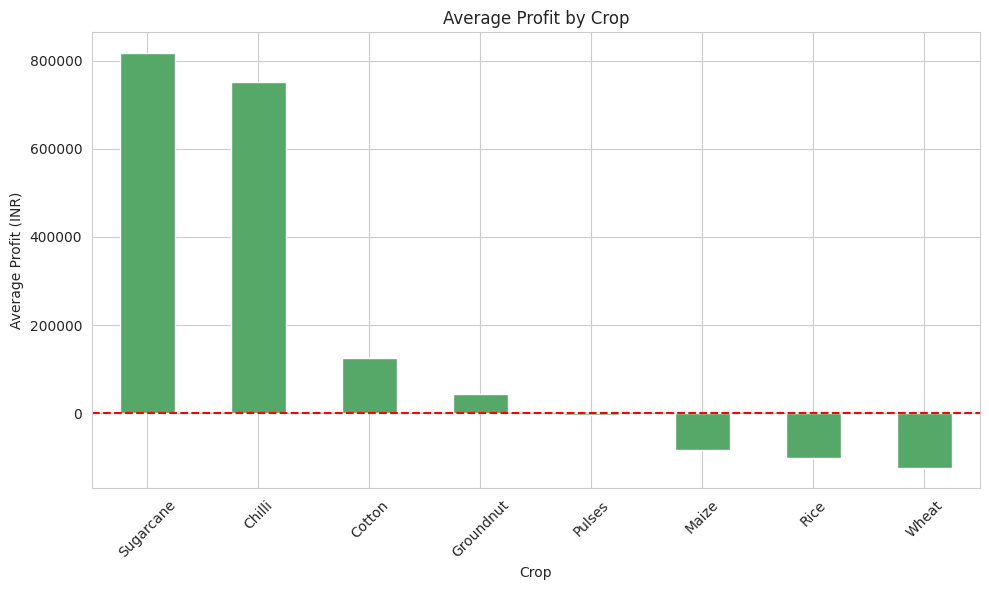

,Profit_INR
Crop,
Sugarcane,817187.986885
Chilli,750878.342233
Cotton,124546.915354
Groundnut,44858.120283
Pulses,-4238.052419
Maize,-83978.326679
Rice,-102213.504348
Wheat,-123398.337134


In [84]:
#Crop vs average Profit
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
crop_profit.plot(kind='bar', color='#55A868')
plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profit by Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
crop_profit


## 10. Multivariate Analysis

Bringing three or more variables together at once.

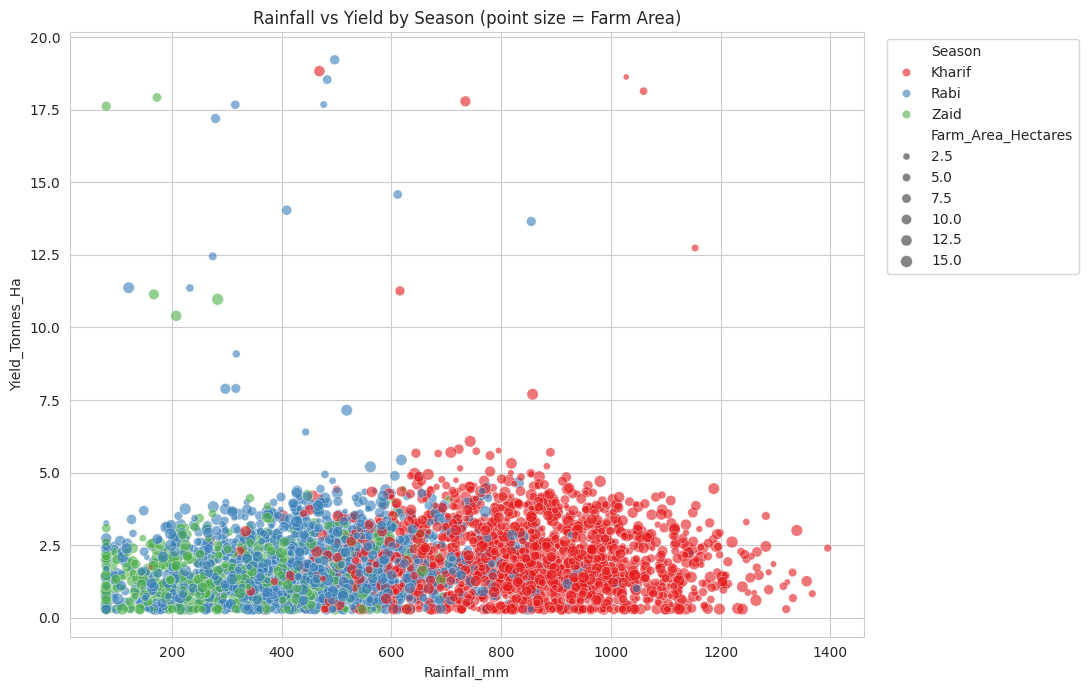

In [85]:
#Rainfall vs Yield, coloured by Season, sized by Farm Area - three variables at once
plt.figure(figsize=(11, 7))
sns.scatterplot(x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', size='Farm_Area_Hectares',
                 data=df[df['Yield_Tonnes_Ha'] < 20], alpha=0.6, palette='Set1',
                 hue_order=['Kharif', 'Rabi', 'Zaid'])
plt.title('Rainfall vs Yield by Season (point size = Farm Area)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


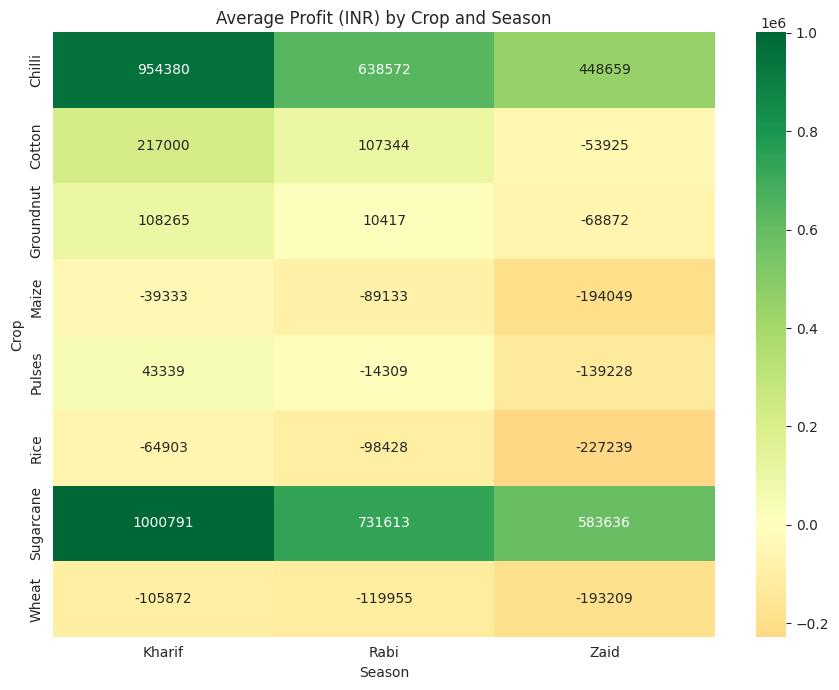

In [86]:
#Average Profit by Crop x Season - heatmap of two categorical dimensions and one numeric measure
pivot_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')
pivot_profit = pivot_profit[['Kharif', 'Rabi', 'Zaid']]

plt.figure(figsize=(9, 7))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.tight_layout()
plt.show()


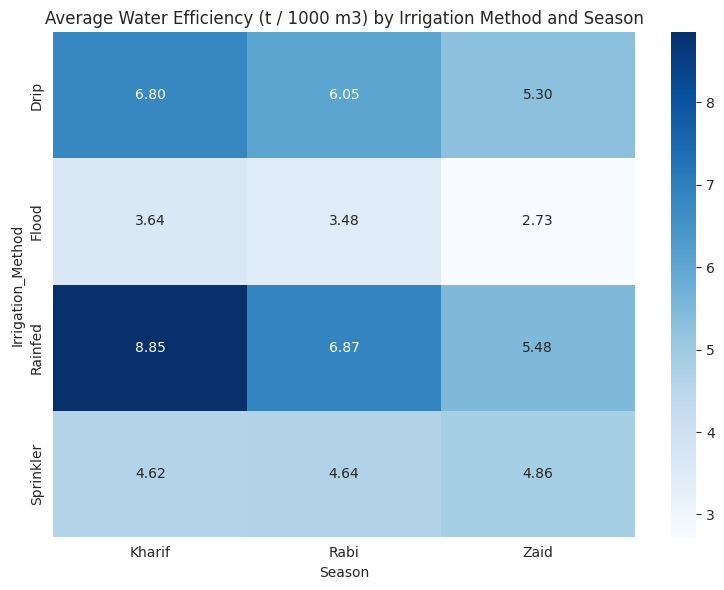

In [87]:
#Water efficiency by Irrigation Method x Season
pivot_wef = df.pivot_table(index='Irrigation_Method', columns='Season',
                            values='Water_Efficiency_t_per_1000m3', aggfunc='mean')
pivot_wef = pivot_wef[['Kharif', 'Rabi', 'Zaid']]

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_wef, annot=True, fmt='.2f', cmap='Blues')
plt.title('Average Water Efficiency (t / 1000 m3) by Irrigation Method and Season')
plt.tight_layout()
plt.show()


## 11. Correlation Analysis

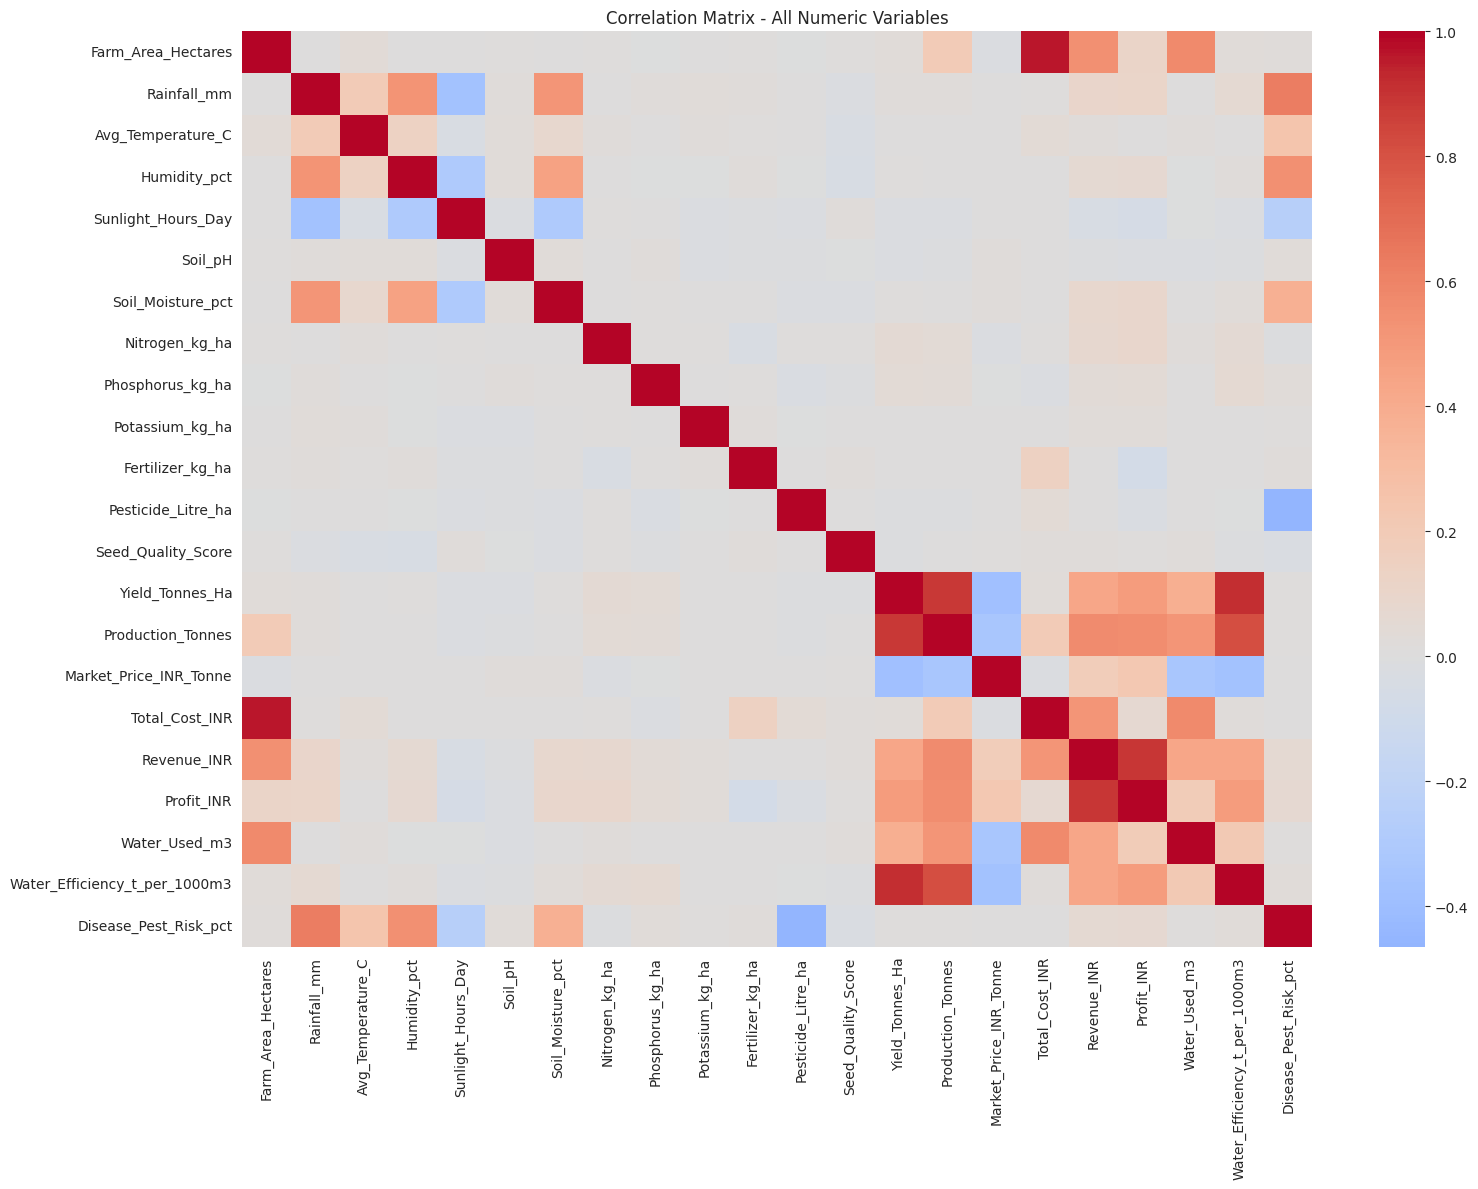

In [88]:
#correlation heatmap of numeric columns
numeric_df = df.select_dtypes(include='number').drop(columns=['Farm_ID'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix - All Numeric Variables')
plt.tight_layout()
plt.show()


In [89]:
#what correlates most strongly with Profit?
corr['Profit_INR'].sort_values(ascending=False)


,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.489328
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.106117
Soil_Moisture_pct,0.092436


In [90]:
#what correlates most strongly with Disease_Pest_Risk_pct?
corr['Disease_Pest_Risk_pct'].sort_values(ascending=False)


,Disease_Pest_Risk_pct
Disease_Pest_Risk_pct,1.000000
Rainfall_mm,0.624405
Humidity_pct,0.545093
Soil_Moisture_pct,0.378607
Avg_Temperature_C,0.245613
Profit_INR,0.067583
Revenue_INR,0.060571
Phosphorus_kg_ha,0.032061
Soil_pH,0.031141
Water_Efficiency_t_per_1000m3,0.029253


## 12. Seasonal Performance Comparison

This is the central question of the project: **how does agricultural performance vary across
Kharif, Rabi and Zaid?** Bringing together environmental conditions, resource usage and economic
outcomes, season by season.

In [91]:
season_order = ['Kharif', 'Rabi', 'Zaid']

seasonal_summary = df.groupby('Season')[[
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
    'Yield_Tonnes_Ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3',
    'Fertilizer_kg_ha', 'Disease_Pest_Risk_pct', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR'
]].mean().reindex(season_order).round(2)

seasonal_summary


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Disease_Pest_Risk_pct,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,,,,,,,,,
Kharif,852.11,28.45,71.81,31.20,5.63,6102.20,5.89,187.03,54.47,531804.41,710719.06,178914.65
Rabi,435.94,23.49,57.89,24.05,5.10,5846.99,5.19,185.34,40.48,513836.58,601526.05,87689.47
Zaid,299.12,31.04,52.01,19.17,4.64,6419.89,4.41,184.51,38.22,543976.73,519171.90,-24804.82


In [92]:
#share of loss-making farms by season
loss_share = df.groupby('Season')['Profit_INR'].apply(lambda x: (x < 0).mean() * 100).reindex(season_order)
loss_share.round(1)


,Profit_INR
Season,
Kharif,42.2
Rabi,51.1
Zaid,64.5


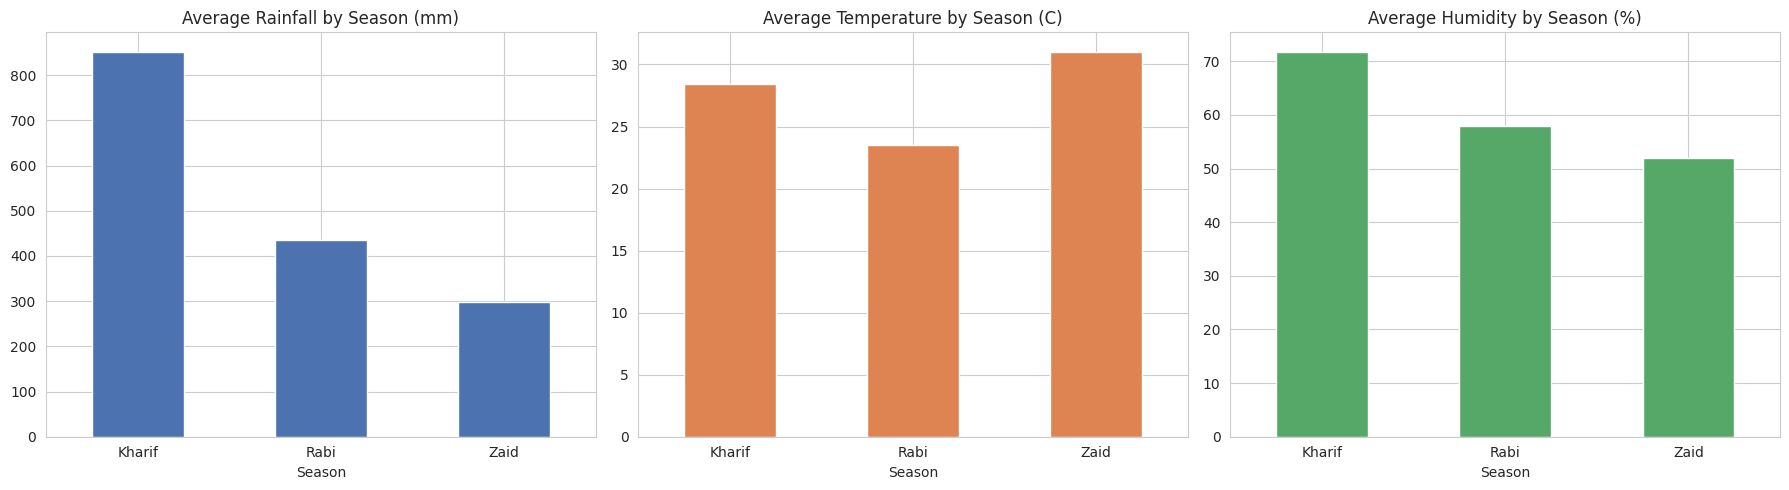

In [93]:
#seasonal dashboard - environmental conditions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
seasonal_summary['Rainfall_mm'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Average Rainfall by Season (mm)')

seasonal_summary['Avg_Temperature_C'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Average Temperature by Season (C)')

seasonal_summary['Humidity_pct'].plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Average Humidity by Season (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


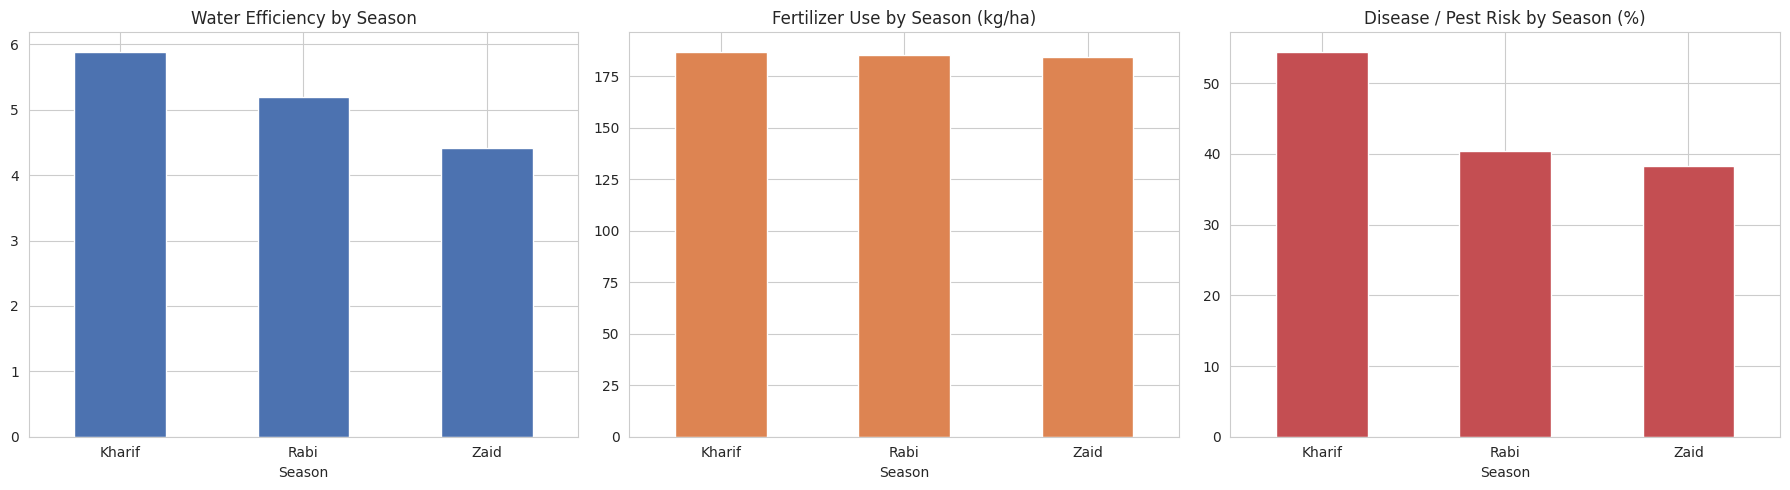

In [94]:
#seasonal dashboard - resource use and risk
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
seasonal_summary['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Water Efficiency by Season')

seasonal_summary['Fertilizer_kg_ha'].plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Fertilizer Use by Season (kg/ha)')

seasonal_summary['Disease_Pest_Risk_pct'].plot(kind='bar', ax=axes[2], color='#C44E52')
axes[2].set_title('Disease / Pest Risk by Season (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


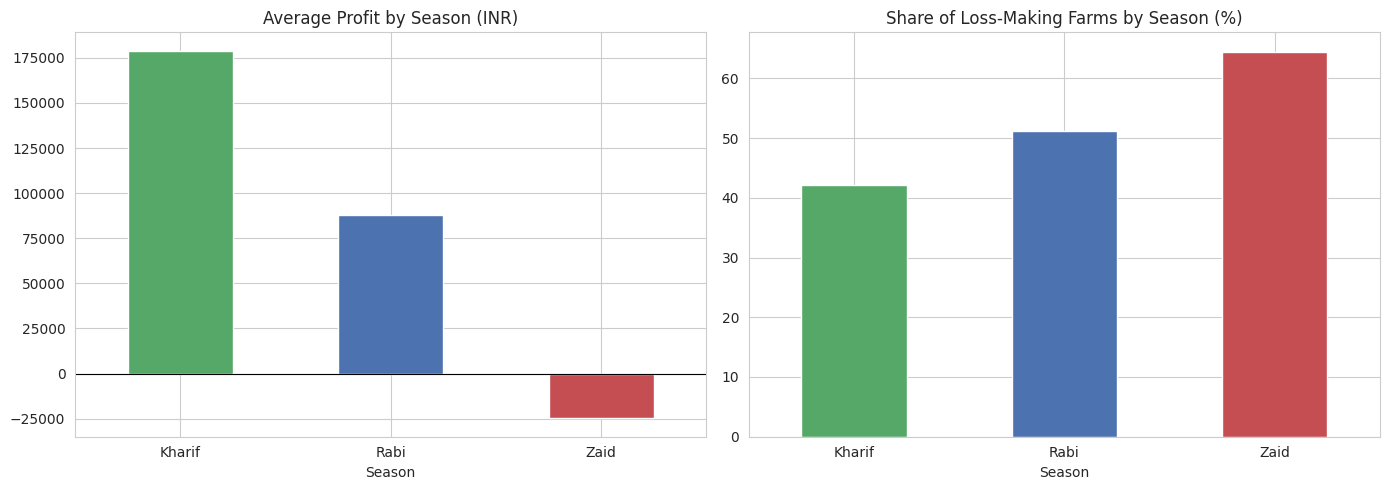

In [95]:
#seasonal dashboard - economic performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seasonal_summary['Profit_INR'].plot(kind='bar', ax=axes[0], color=['#55A868', '#4C72B0', '#C44E52'])
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Profit by Season (INR)')

loss_share.plot(kind='bar', ax=axes[1], color=['#55A868', '#4C72B0', '#C44E52'])
axes[1].set_title('Share of Loss-Making Farms by Season (%)')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


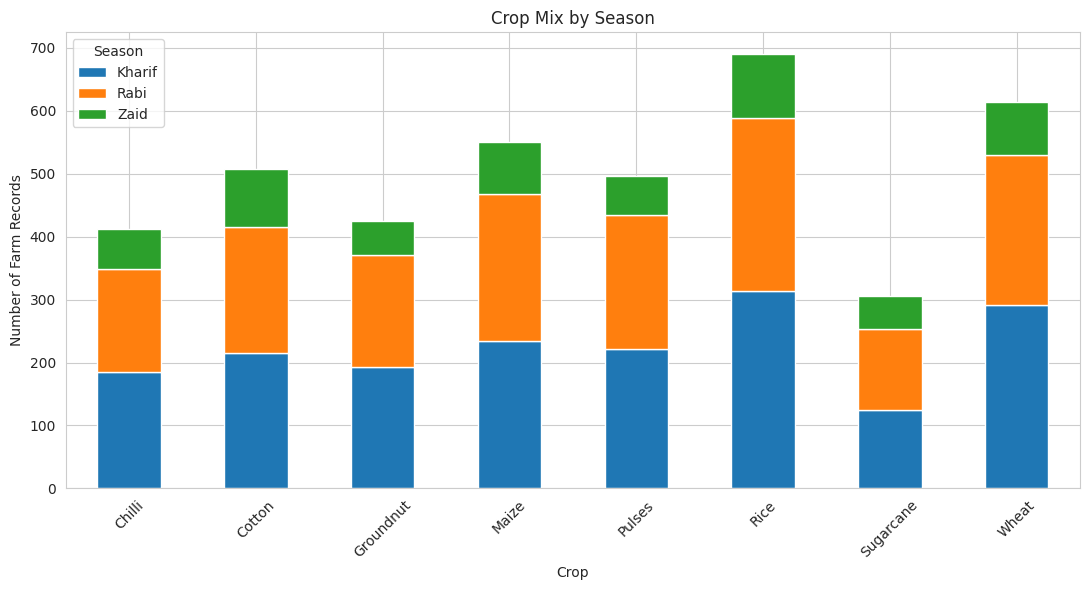

In [96]:
#seasonal crop mix - which crops are actually grown in which season?
plt.figure(figsize=(11, 6))
crop_season_counts = pd.crosstab(df['Crop'], df['Season'])[season_order]
crop_season_counts.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Crop Mix by Season')
plt.ylabel('Number of Farm Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13. Student-Designed Analysis 1 — What Separates Profitable Farms from Loss-Making Farms?

Close to half of all farm records in this dataset show a **negative profit**. Rather than only
reporting the average, this analysis compares profitable vs loss-making farms directly to see what
actually differs between them.

In [97]:
df['Profitable'] = np.where(df['Profit_INR'] >= 0, 'Profitable', 'Loss-making')

compare_cols = ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Fertilizer_kg_ha',
                'Disease_Pest_Risk_pct', 'Market_Price_INR_Tonne', 'Total_Cost_INR']

comparison = df.groupby('Profitable')[compare_cols].mean().round(2)
comparison


,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,Fertilizer_kg_ha,Disease_Pest_Risk_pct,Market_Price_INR_Tonne,Total_Cost_INR
Profitable,,,,,,
Loss-making,1.61,2.69,191.86,45.11,37701.01,539751.77
Profitable,8.80,7.99,180.27,47.58,51492.86,513304.99


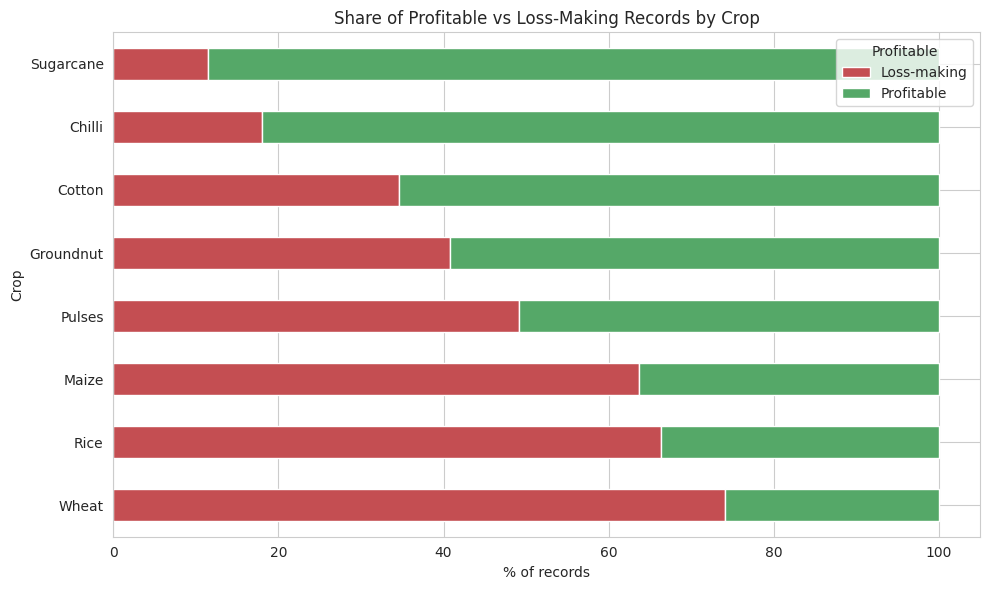

In [98]:
#Profitable vs Loss-making, split by Crop
profit_by_crop = pd.crosstab(df['Crop'], df['Profitable'], normalize='index') * 100
profit_by_crop = profit_by_crop.sort_values('Loss-making', ascending=False)

plt.figure(figsize=(10, 6))
profit_by_crop.plot(kind='barh', stacked=True, ax=plt.gca(), color=['#C44E52', '#55A868'])
plt.title('Share of Profitable vs Loss-Making Records by Crop')
plt.xlabel('% of records')
plt.tight_layout()
plt.show()


In [99]:
#Profitable vs Loss-making, split by Irrigation Method
profit_by_irrig = pd.crosstab(df['Irrigation_Method'], df['Profitable'], normalize='index') * 100
profit_by_irrig.round(1)


Profitable,Loss-making,Profitable
Irrigation_Method,,
Drip,40.2,59.8
Flood,52.8,47.2
Rainfed,53.1,46.9
Sprinkler,48.1,51.9


**Reading this analysis:** Loss-making records are not spread evenly across crops or irrigation
methods. Wheat, Rice and Maize (grain crops with lower revenue per tonne) carry a much higher share of
loss-making records than Sugarcane and Chilli. Water efficiency is consistently lower for the
loss-making group, pointing to resource use — not just market price — as part of the profitability
gap.

## 14. Student-Designed Analysis 2 — Irrigation Method Efficiency and Its Cost-Benefit Trade-off

The dataset records four irrigation methods (Drip, Sprinkler, Flood, Rainfed). Drip and Sprinkler
systems cost more to install/operate, so this analysis checks whether that cost is justified by better
water efficiency and profit outcomes.

In [100]:
irrig_summary = df.groupby('Irrigation_Method')[[
    'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Yield_Tonnes_Ha',
    'Total_Cost_INR', 'Profit_INR'
]].mean().sort_values('Water_Efficiency_t_per_1000m3', ascending=False).round(2)
irrig_summary


,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,Total_Cost_INR,Profit_INR
Irrigation_Method,,,,,
Rainfed,3549.55,7.56,4.60,505303.61,79050.37
Drip,5918.75,6.27,6.68,534945.24,219626.00
Sprinkler,6208.26,4.67,5.16,526609.22,91121.08
Flood,8026.47,3.44,4.86,536784.13,73354.02


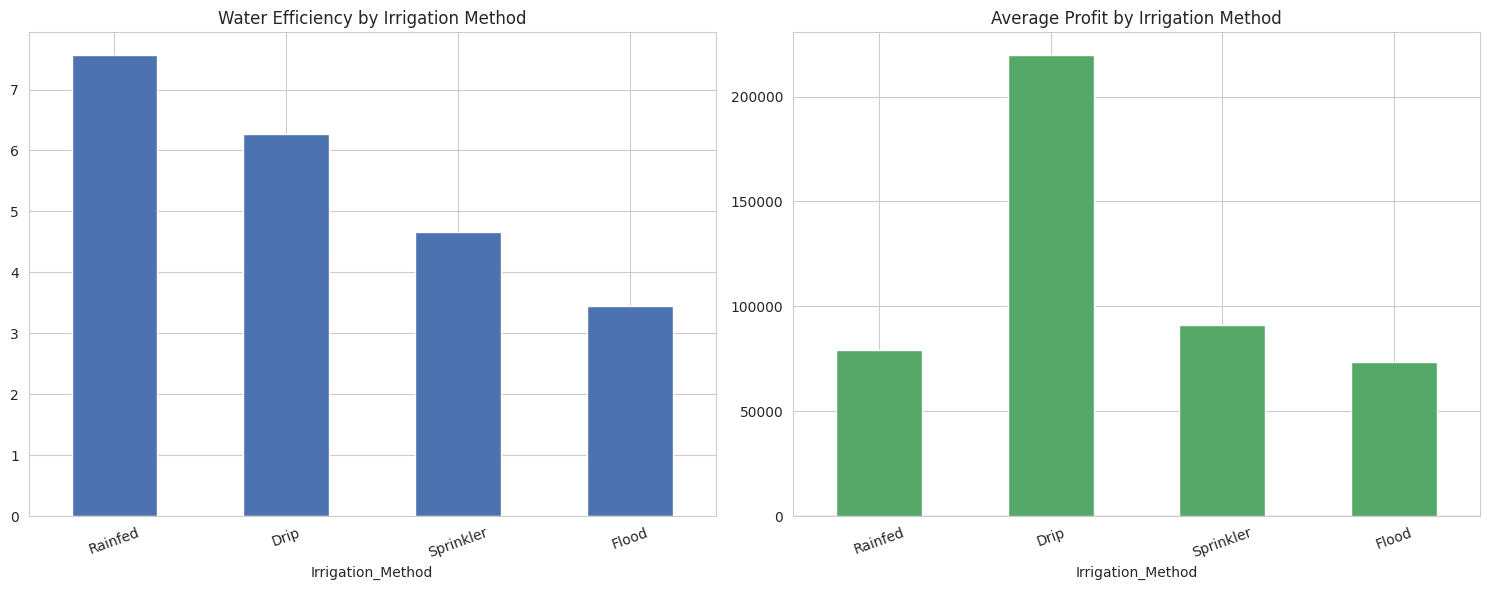

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
irrig_summary['Water_Efficiency_t_per_1000m3'].plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Water Efficiency by Irrigation Method')
axes[0].tick_params(axis='x', rotation=20)

irrig_summary['Profit_INR'].plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Profit by Irrigation Method')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


In [102]:
#does the irrigation-method effect hold up within season, or is it just a seasonal mix effect?
irrig_season = df.pivot_table(index='Irrigation_Method', columns='Season',
                               values='Water_Efficiency_t_per_1000m3', aggfunc='mean')[season_order]
irrig_season.round(2)


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,6.80,6.05,5.30
Flood,3.64,3.48,2.73
Rainfed,8.85,6.87,5.48
Sprinkler,4.62,4.64,4.86


**Reading this analysis:** Rainfed plots show the highest water-efficiency figure, but that is
expected — "water used" for rainfed farming does not include the cost/effort of delivering that water,
unlike Drip or Sprinkler systems, so the comparison is not entirely like-for-like. The more telling
number is **profit**: Drip-irrigated farms average **₹219,626** profit — roughly 2.5–3x higher than
Rainfed (₹79,050), Sprinkler (₹91,121) or Flood (₹73,354) — while also being more water-efficient than
Flood across every single season. Flood remains the most commonly used method in the dataset (1,310
records) despite being both the least water-efficient and the least profitable, pointing to a clear,
practical opportunity to shift Flood-irrigated farms toward Drip.


## 15. Student-Designed Analysis 3 — Environmental Drivers of Disease / Pest Risk

`Disease_Pest_Risk_pct` is one of the few columns not directly tied to money. This analysis checks
which environmental conditions are most associated with higher disease/pest risk, and whether that
risk actually differs by season.

In [103]:
risk_corr = df[['Rainfall_mm', 'Humidity_pct', 'Soil_Moisture_pct', 'Avg_Temperature_C',
                'Disease_Pest_Risk_pct']].corr()['Disease_Pest_Risk_pct'].sort_values(ascending=False)
risk_corr


,Disease_Pest_Risk_pct
Disease_Pest_Risk_pct,1.000000
Rainfall_mm,0.624405
Humidity_pct,0.545093
Soil_Moisture_pct,0.378607
Avg_Temperature_C,0.245613


/tmp/ipykernel_6827/3428797730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df, order=season_order, ax=axes[1], palette='Set2')


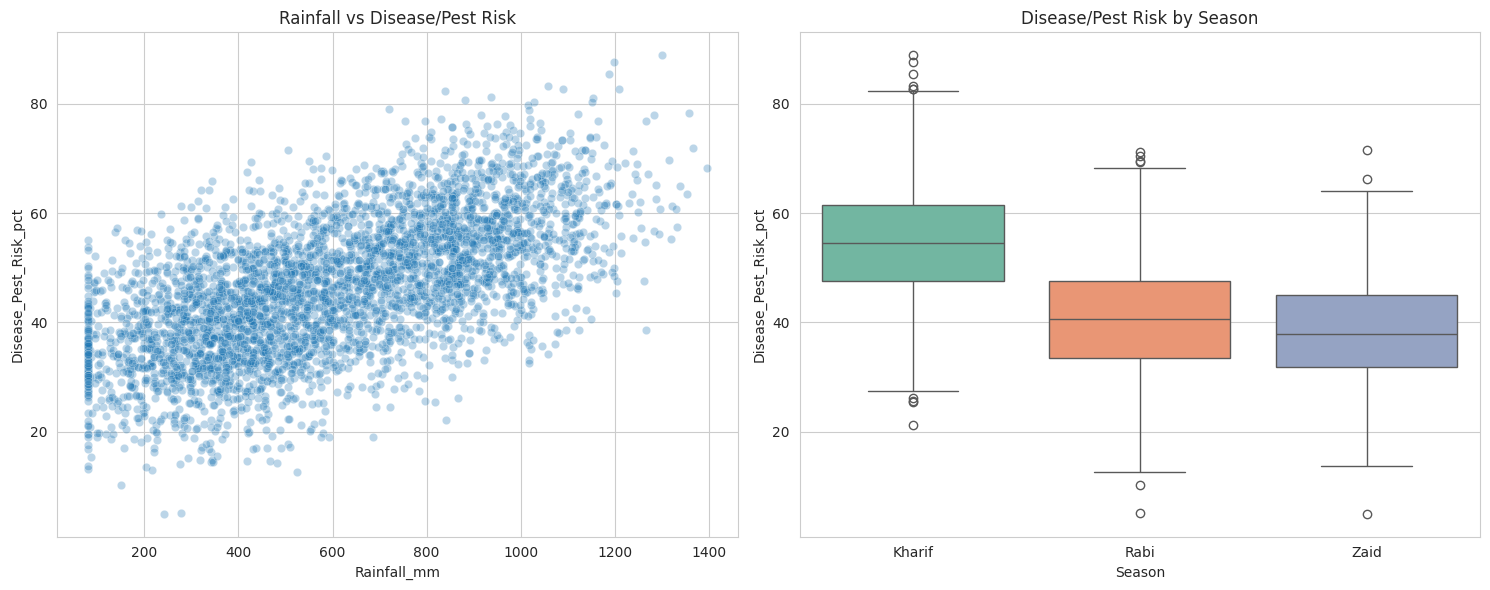

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x='Rainfall_mm', y='Disease_Pest_Risk_pct', data=df, alpha=0.3, ax=axes[0])
axes[0].set_title('Rainfall vs Disease/Pest Risk')

sns.boxplot(x='Season', y='Disease_Pest_Risk_pct', data=df, order=season_order, ax=axes[1], palette='Set2')
axes[1].set_title('Disease/Pest Risk by Season')
plt.tight_layout()
plt.show()


In [105]:
#which crops carry the highest disease/pest risk, and in which season?
risk_by_crop_season = df.pivot_table(index='Crop', columns='Season',
                                      values='Disease_Pest_Risk_pct', aggfunc='mean')[season_order]
risk_by_crop_season.round(1).sort_values('Kharif', ascending=False)


Season,Kharif,Rabi,Zaid
Crop,,,
Wheat,55.6,41.5,39.2
Pulses,55.0,40.1,39.0
Maize,54.8,39.4,36.7
Groundnut,54.3,39.8,39.1
Rice,54.3,40.8,37.9
Cotton,54.2,41.5,36.3
Sugarcane,54.0,39.8,38.4
Chilli,52.8,40.6,40.5


**Reading this analysis:** Disease/pest risk correlates most strongly with **Rainfall** and
**Humidity** — both of which peak in Kharif (the monsoon season). This lines up directly with the
seasonal comparison in Section 12, where Kharif also has the highest average disease/pest risk of the
three seasons.

## 16. My Key Insights

Alright, after diving deep into the data, here are the most important things we've learned:

1.  **Kharif is our star performer for profit, while Zaid often ends up in the red.** On average, farms in Kharif pull in a solid ₹178,915, and Rabi isn't far behind at ₹87,689. But here's the kicker: Zaid season actually averages **-₹24,805**—making it the only time of year where the typical farm record *loses* money.

2.  **It seems more and more farms hit a loss as the year goes on.** In Kharif, about 42.2% of our records show a loss. This creeps up to 51.1% in Rabi and then jumps significantly to **64.5% in Zaid**. Overall, almost half (49.2%) of all 4,000 farm records in our dataset are facing losses.

3.  **Rainfall is the biggest seasonal tell.** The average rainfall takes a huge dive, from 852 mm in Kharif down to 436 mm in Rabi, and then to a measly 299 mm in Zaid. This nearly three-fold drop perfectly mirrors lower yields, less efficient water use, and reduced profits in the same order.

4.  **Disease and pest risk is more about rain and humidity than temperature.** We found that `Rainfall_mm` (with a correlation of 0.62) and `Humidity_pct` (correlation 0.55) are much stronger predictors of `Disease_Pest_Risk_pct` compared to `Avg_Temperature_C` (correlation 0.25). And guess what? Kharif (our wettest, most humid season) predictably has the highest average disease/pest risk at 54.5%, versus a much lower ~38-40% in Rabi and Zaid.

5.  **Picking the right crop has a bigger impact on profit than the season itself.** The average profit can swing wildly, from a high of **+₹817,188** for Sugarcane all the way down to **-₹123,398** for Wheat. This range is way bigger than the profit differences we see between any two seasons. Interestingly, Wheat, Rice, and Maize are the only three crops that consistently show a negative average profit.

6.  **When it comes to irrigation, Drip consistently beats Flood for both efficiency and profit.** Flood irrigation is super common in our dataset (1,310 out of 4,000 records), but it's also the **least** water-efficient (3.44 t / 1000 m³) and brings in the lowest average profit (₹73,354). Drip irrigation, used less than a third as often (915 records), is nearly twice as water-efficient (6.27 t / 1000 m³) and nets an average profit of **₹219,626**—that's roughly three times higher!

7.  **Those 'outliers' in yield and water use? Mostly real, crop-specific variations, not mistakes.** For example, out of 276 `Water_Used_m3` values flagged by the IQR rule, 168 belong to Rice and 105 to Sugarcane. Both are genuinely water-hungry crops, confirming these are real differences in farming, not issues with our data.

8.  **Water efficiency and profit go hand-in-hand.** `Water_Efficiency_t_per_1000m3` has a strong positive connection with `Profit_INR` (0.49). This is almost as strong as the correlation with `Yield_Tonnes_Ha` itself (0.49), suggesting that being smart about water isn't just good for the planet, it's great for the wallet too.

9.  **Your total costs don't really tell you much about your profit (correlation of 0.07).** Simply spending more doesn't reliably lead to bigger profits in this dataset. What a farm *earns* (`Revenue_INR`, with a strong correlation of 0.89) matters way, *way* more than what it spends.


## 17. Actionable Recommendations (Based on What I Found)

Based on all our digging, here are some practical steps we can take:

*   **Let's prioritize support for the Zaid season, treating it as the riskiest time for farmers.** With 64.5% of Zaid records showing a loss and being the only season with a negative average profit, programs like seasonal credit, insurance, and subsidies should really focus on Zaid-season farmers.

*   **We should actively push Drip irrigation over Flood, especially for Rice and Sugarcane growers.** Drip is about 1.8 times more water-efficient and averages roughly three times higher profit (₹219,626 vs. ₹73,354) than Flood. Since Rice and Sugarcane are the biggest water users, helping these farms switch could have the largest combined impact on efficiency and profitability.

*   **Time to step up disease and pest monitoring, particularly before and during the Kharif season.** Since risk seems to follow rainfall and humidity more than temperature, setting up early-warning systems linked to monsoon forecasts would be much more effective than relying on temperature-based alerts.

*   **It might be worth encouraging Wheat, Rice, and Maize growers to rethink their crop choices.** These are the only three crops in our dataset that show a negative average profit. Where it makes sense, helping farmers diversify into higher-margin crops like Cotton or Groundnut, alongside their usual staples, could really boost their income without completely abandoning essential food crops.

*   **Let's focus on strategies that boost revenue (like better market access or pricing) instead of just cutting costs.** Our analysis clearly shows that total costs have almost no connection to profit (a correlation of just 0.07), while revenue has a very strong one (0.89). This means programs purely aimed at cutting input costs probably won't move the profit needle much on their own.

## 18. Important Things to Keep in Mind & Limitations

Every analysis has its boundaries, so here's what to remember when you're looking at our findings:

*   **The State-District pairings look a bit odd.** In this dataset, some states are matched with districts that actually belong to other real states (for example, "Rajkot" shows up under different states). This means our dataset doesn't really reflect India's actual farming geography. Because of this, we deliberately kept state- and district-level comparisons to a minimum, and any results from those shouldn't be taken as genuine regional insights.

*   **This is a snapshot, not a movie.** Each row shows a single farm in one season. We don't track the *same* farm over several years, so we can't look at trends over time (like how a farm improves year after year). We can only see the differences across the three seasons in this particular moment.

*   **Correlation isn't causation!** When we see relationships, like 'higher water efficiency goes with higher profit,' these are just statistical connections within *this* dataset. They don't automatically prove that making one better directly *causes* the other to improve. Other factors we didn't measure (like soil quality, how experienced the farmer is, or local market access) could be playing a role in both.

*   **We filled in a few missing gaps, which subtly affects things.** We used median imputation for `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`. Each of these affected less than 1.2% of our data, so it's a small change, but it does slightly smooth out the natural variation in those columns.

*   **The Zaid season is a bit underrepresented.** Zaid only accounts for 594 out of 4,000 records, compared to 1,779 for Kharif and 1,627 for Rabi. This means any conclusions we draw about Zaid are based on a smaller sample and might have a bit more uncertainty.

## 19. Wrapping Up: My Final Thoughts

>



Our analysis clearly shows that farming performance in this dataset changes quite a bit across the three seasons. **Kharif consistently comes out on top**, with the most rain, highest yields, and biggest profits, although it also brings the highest risk of diseases and pests. On the flip side, **Zaid is financially the toughest season**, with most of its records actually showing a loss.

But here's a key insight: the season isn't the *only*, or even the *biggest*, factor driving how well a farm does. **The specific crop a farmer chooses and their irrigation method actually create much larger differences in profit and water efficiency than seasonal changes alone.** For example, Sugarcane and Chilli farms are almost always profitable, regardless of the season, while Wheat, Rice, and Maize often struggle. Similarly, Drip irrigation consistently outperforms the much more common Flood method when it comes to water efficiency.

So, putting it all together, our analysis suggests a two-pronged approach for smart seasonal agricultural planning:

1.  **Tailored support for each season is definitely needed.** This is especially true for helping farmers reduce risks during the Zaid season and managing the higher disease/pest pressure in Kharif.

2.  **This support should also include specific advice for different crops and irrigation methods.** These two factors explain differences in outcomes that are at least as significant as the seasonal variations we initially set out to explore.